## 1. Target-Class Distribution

The target distribution is examined to determine whether the classification
problem is balanced. Understanding class imbalance is important because
accuracy alone may provide a misleading evaluation of model performance.

For this project:

- Class 0 represents a PHQ-9 score below 10.
- Class 1 represents a PHQ-9 score of 10 or higher.

Because the positive class is considerably smaller, stratified data splitting
and imbalance-aware evaluation metrics will be required during modeling.

In [2]:
# Import the required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the visualization style
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
)

# Load the preprocessed dataset
data_file = Path(
    "../data/processed/"
    "nhanes_2017_2018_preprocessed.csv"
)

eda_df = pd.read_csv(data_file)

# Define the target variable
target_column = "elevated_depression_risk"

print("Setup completed successfully.")
print("Dataset shape:", eda_df.shape)

Setup completed successfully.
Dataset shape: (5068, 31)


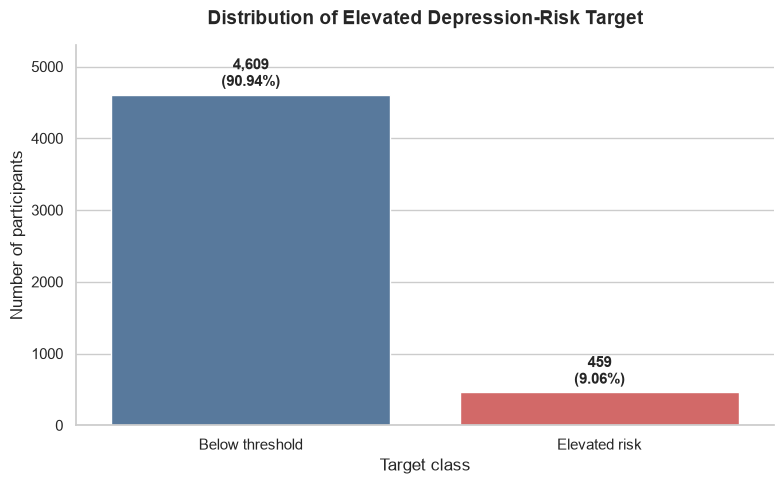

,target,count,percentage,class_label
0,0,4609,90.94,Below threshold
1,1,459,9.06,Elevated risk


In [3]:
# Create a folder for saving report-quality figures
figures_folder = Path("../reports/figures")
figures_folder.mkdir(
    parents=True,
    exist_ok=True,
)

# Calculate target counts
target_summary = (
    eda_df[target_column]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)

# Calculate target percentages
target_summary["percentage"] = (
    target_summary["count"]
    / len(eda_df)
    * 100
).round(2)

# Add readable class labels
target_labels = {
    0: "Below threshold",
    1: "Elevated risk",
}

target_summary["class_label"] = (
    target_summary["target"]
    .map(target_labels)
)

# Create the target-distribution chart
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=target_summary,
    x="class_label",
    y="count",
    hue="class_label",
    palette={
        "Below threshold": "#4C78A8",
        "Elevated risk": "#E45756",
    },
    legend=False,
    ax=ax,
)

# Add count and percentage labels above each bar
for index, row in target_summary.iterrows():
    ax.text(
        index,
        row["count"] + 60,
        f'{row["count"]:,}\n({row["percentage"]:.2f}%)',
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Format the visualization
ax.set_title(
    "Distribution of Elevated Depression-Risk Target",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Target class")
ax.set_ylabel("Number of participants")
ax.set_ylim(
    0,
    target_summary["count"].max() * 1.15,
)

sns.despine()
plt.tight_layout()

# Save a high-resolution version for the final report
target_figure_file = (
    figures_folder
    / "target_class_distribution.png"
)

fig.savefig(
    target_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Display the exact values
target_summary

## 2. Continuous Feature Distributions

Histograms are used to examine the distributions, spread, skewness, and
potential extreme values of important continuous predictors.

The median is displayed as a dashed vertical line. Missing values are
excluded from each visualization but remain in the dataset for later
pipeline-based imputation.

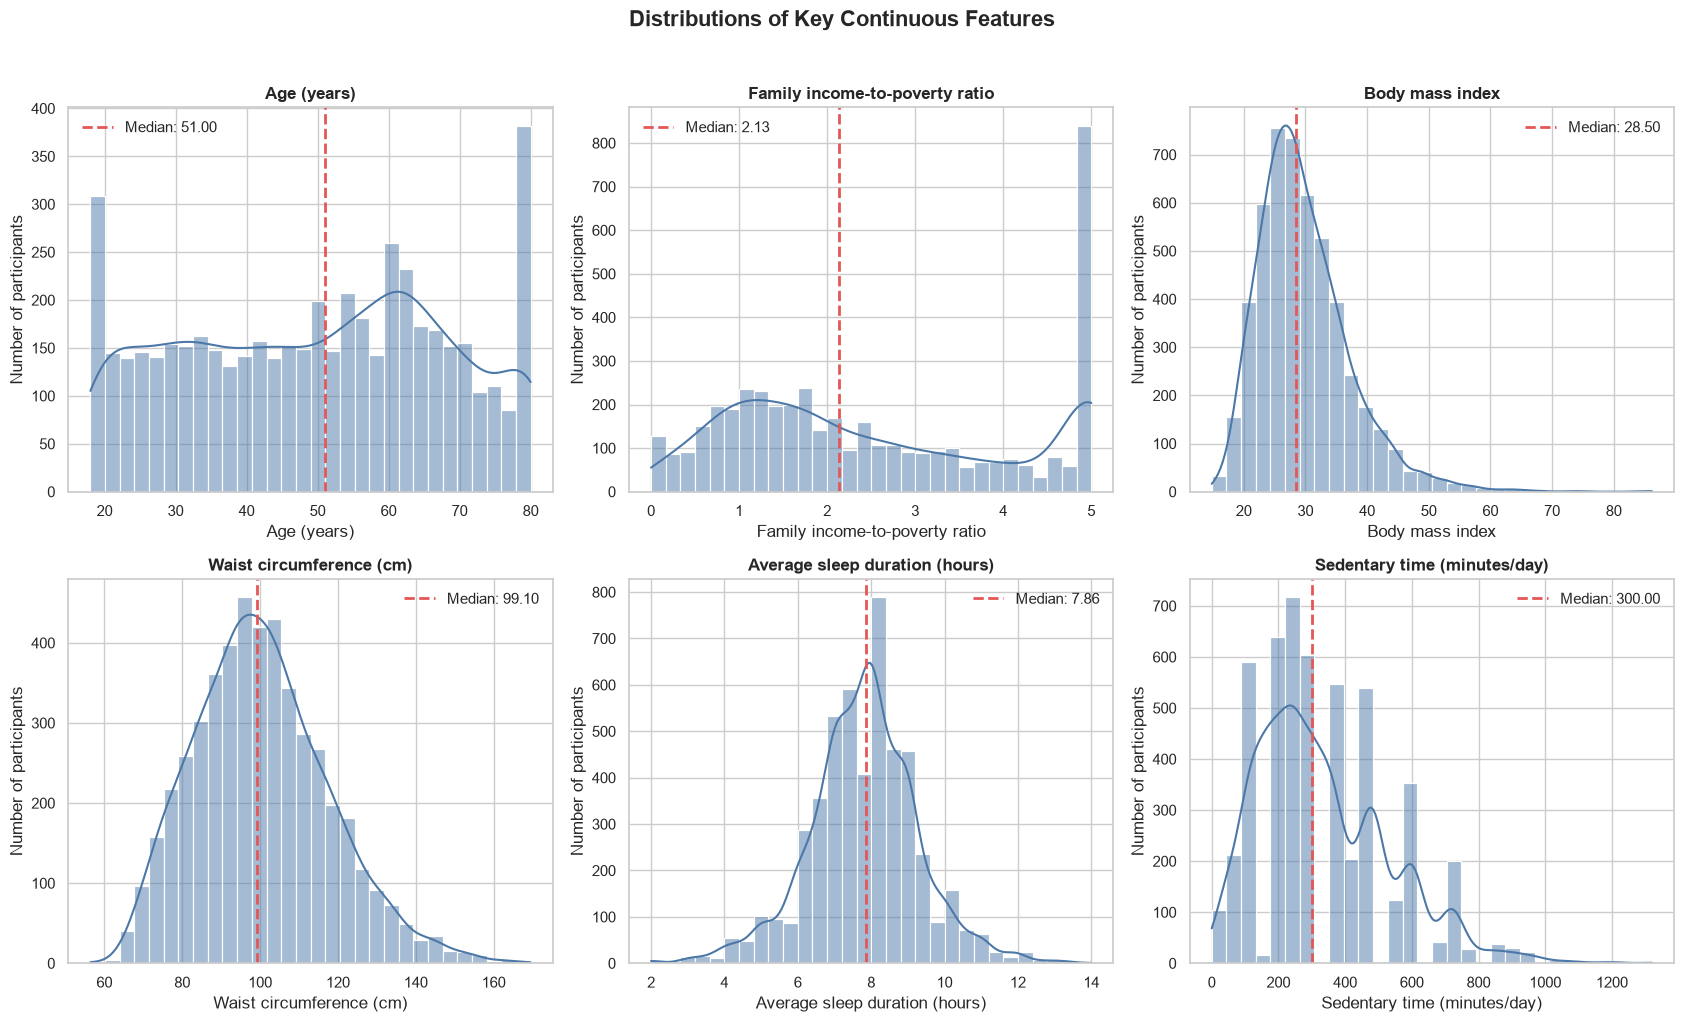

Continuous-feature distribution figure saved.
Saved location: ../reports/figures/continuous_feature_distributions.png


In [4]:
# Select the primary continuous features for visualization
continuous_eda_features = {
    "RIDAGEYR": "Age (years)",
    "INDFMPIR": "Family income-to-poverty ratio",
    "BMXBMI": "Body mass index",
    "BMXWAIST": "Waist circumference (cm)",
    "average_sleep_hours": "Average sleep duration (hours)",
    "sedentary_minutes_per_day": "Sedentary time (minutes/day)",
}

# Create a grid of histograms
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(17, 10),
)

# Flatten the axes so they can be used in a loop
axes = axes.flatten()

# Draw one distribution for each continuous feature
for ax, (feature, label) in zip(
    axes,
    continuous_eda_features.items(),
):
    # Calculate the median while excluding missing values
    feature_median = eda_df[feature].median()

    # Plot the feature distribution
    sns.histplot(
        data=eda_df,
        x=feature,
        bins=30,
        kde=True,
        color="#4C78A8",
        edgecolor="white",
        ax=ax,
    )

    # Add a vertical line showing the median
    ax.axvline(
        feature_median,
        color="#E45756",
        linestyle="--",
        linewidth=2,
        label=f"Median: {feature_median:.2f}",
    )

    # Format the subplot
    ax.set_title(
        label,
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Number of participants")
    ax.legend(frameon=False)

# Add an overall figure title
fig.suptitle(
    "Distributions of Key Continuous Features",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

# Save the figure for the final report
continuous_figure_file = (
    figures_folder
    / "continuous_feature_distributions.png"
)

fig.savefig(
    continuous_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Continuous-feature distribution figure saved.")
print("Saved location:", continuous_figure_file)

### Continuous Distribution Findings

The continuous variables show several important distribution patterns:

- Participant ages cover a broad adult range. The concentration at age 80
  reflects the NHANES top-coded age category.
- The family income-to-poverty ratio is right-skewed and capped at 5.
- BMI and waist circumference are moderately right-skewed, indicating a
  smaller number of participants with high body measurements.
- Average sleep duration is centered near eight hours and is approximately
  bell-shaped.
- Sedentary time is right-skewed and contains clusters at rounded values,
  which is common in self-reported duration data.

These patterns support the use of scaling for magnitude-sensitive models.
Potential transformations will be evaluated within the training pipeline.

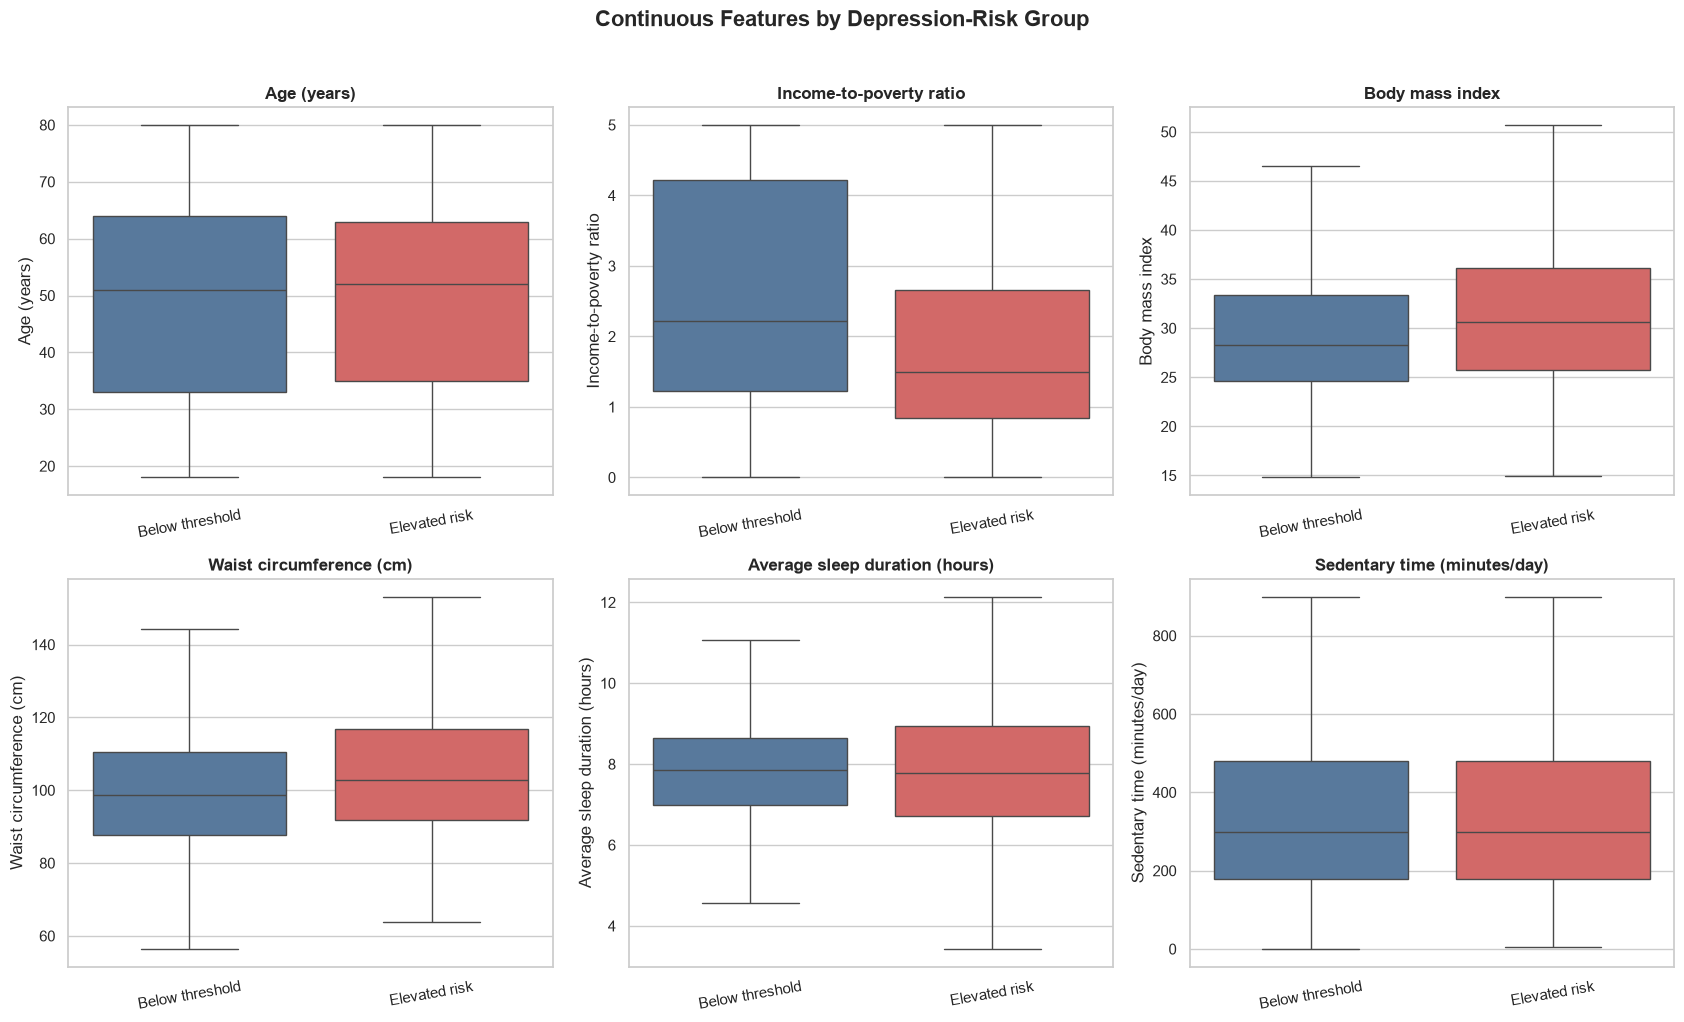

Target-group comparison figure saved.
Saved location: ../reports/figures/continuous_features_by_target.png


In [5]:
# Create readable target labels for visualization
eda_df["risk_group"] = eda_df[target_column].map({
    0: "Below threshold",
    1: "Elevated risk",
})

# Define readable names for the comparison plots
comparison_features = {
    "RIDAGEYR": "Age (years)",
    "INDFMPIR": "Income-to-poverty ratio",
    "BMXBMI": "Body mass index",
    "BMXWAIST": "Waist circumference (cm)",
    "average_sleep_hours": "Average sleep duration (hours)",
    "sedentary_minutes_per_day": "Sedentary time (minutes/day)",
}

# Create a grid of boxplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(17, 10),
)

axes = axes.flatten()

# Compare each continuous variable across target groups
for ax, (feature, label) in zip(
    axes,
    comparison_features.items(),
):
    sns.boxplot(
        data=eda_df,
        x="risk_group",
        y=feature,
        hue="risk_group",
        palette={
            "Below threshold": "#4C78A8",
            "Elevated risk": "#E45756",
        },
        legend=False,
        showfliers=False,
        ax=ax,
    )

    ax.set_title(
        label,
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(
        axis="x",
        rotation=10,
    )

# Add an overall title
fig.suptitle(
    "Continuous Features by Depression-Risk Group",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

# Save the figure
comparison_figure_file = (
    figures_folder
    / "continuous_features_by_target.png"
)

fig.savefig(
    comparison_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Target-group comparison figure saved.")
print("Saved location:", comparison_figure_file)

### Continuous Feature Comparison Findings

Participants in the elevated-risk group generally show a lower
income-to-poverty ratio and higher BMI and waist circumference. Age and
sedentary-time distributions appear relatively similar between groups.

Average sleep duration has a similar median in both groups, although the
elevated-risk group shows somewhat greater variability. These descriptive
differences represent associations only and do not demonstrate causation.

## 3. Categorical Feature Analysis

For categorical features, the percentage of elevated-risk participants is
more informative than raw counts because the target is imbalanced. The
following charts compare elevated-risk rates across demographic and
behavioral categories.

Categories with smaller sample sizes should be interpreted cautiously.

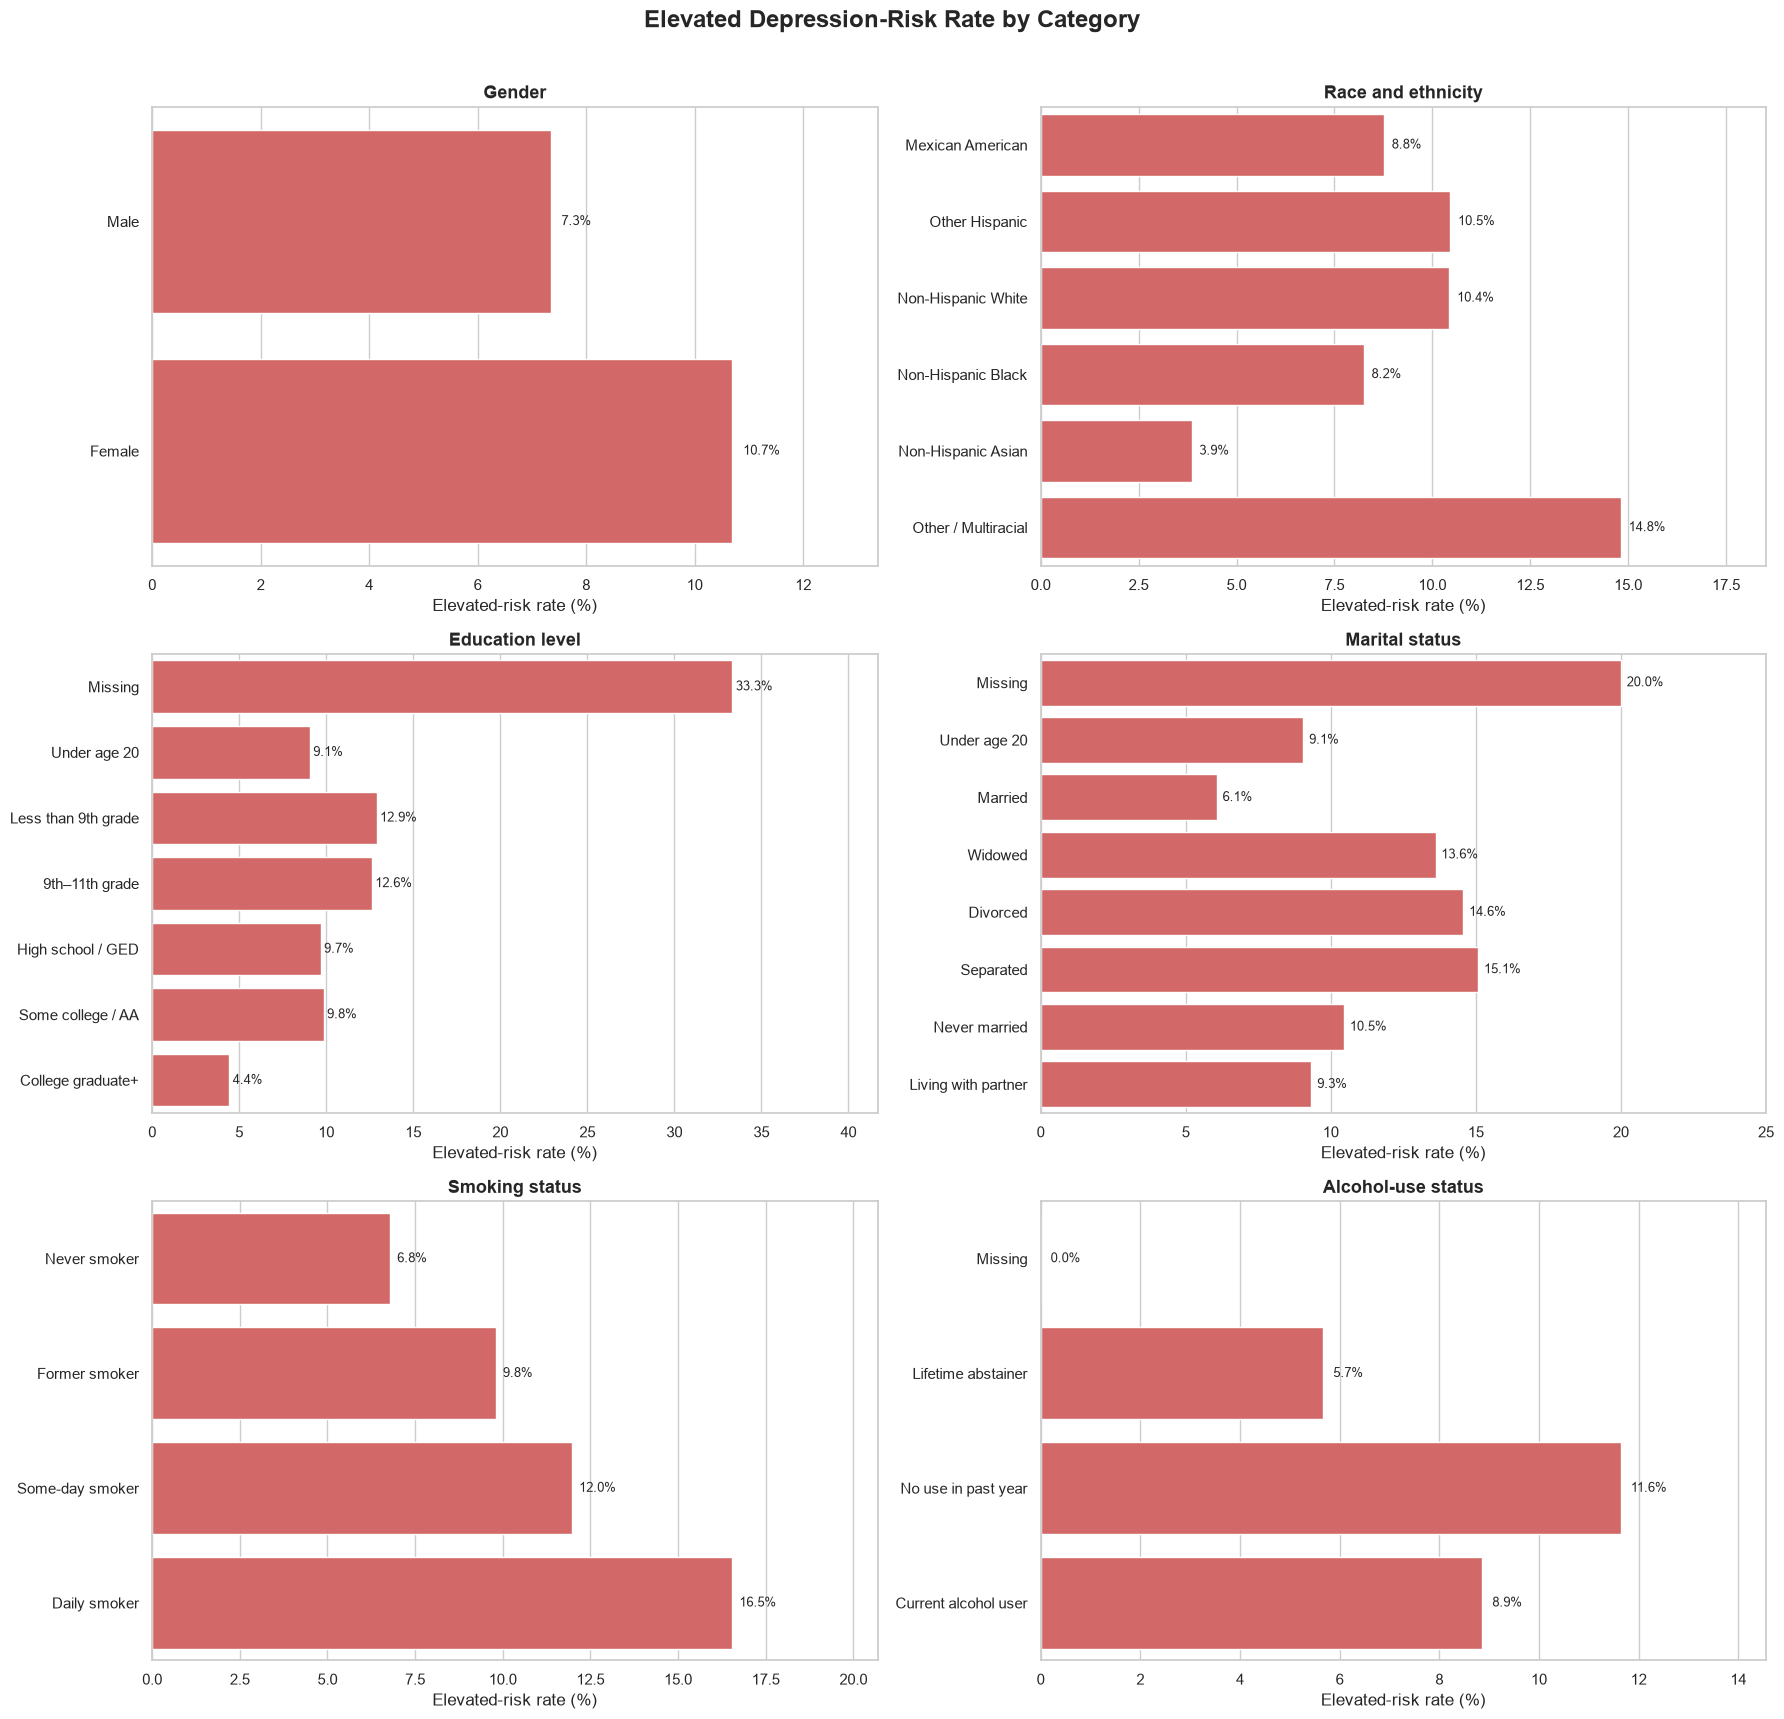

Categorical risk-rate figure saved.
Saved location: ../reports/figures/categorical_elevated_risk_rates.png


In [6]:
# Define readable category labels
categorical_label_maps = {
    "RIAGENDR": {
        -1: "Missing",
        1: "Male",
        2: "Female",
    },
    "RIDRETH3": {
        -1: "Missing",
        1: "Mexican American",
        2: "Other Hispanic",
        3: "Non-Hispanic White",
        4: "Non-Hispanic Black",
        6: "Non-Hispanic Asian",
        7: "Other / Multiracial",
    },
    "DMDEDUC2": {
        -1: "Missing",
        0: "Under age 20",
        1: "Less than 9th grade",
        2: "9th–11th grade",
        3: "High school / GED",
        4: "Some college / AA",
        5: "College graduate+",
    },
    "DMDMARTL": {
        -1: "Missing",
        0: "Under age 20",
        1: "Married",
        2: "Widowed",
        3: "Divorced",
        4: "Separated",
        5: "Never married",
        6: "Living with partner",
    },
    "smoking_status": {
        -1: "Missing",
        0: "Never smoker",
        1: "Former smoker",
        2: "Some-day smoker",
        3: "Daily smoker",
    },
    "alcohol_use_status": {
        -1: "Missing",
        0: "Lifetime abstainer",
        1: "No use in past year",
        2: "Current alcohol user",
    },
}

# Define professional subplot titles
categorical_titles = {
    "RIAGENDR": "Gender",
    "RIDRETH3": "Race and ethnicity",
    "DMDEDUC2": "Education level",
    "DMDMARTL": "Marital status",
    "smoking_status": "Smoking status",
    "alcohol_use_status": "Alcohol-use status",
}

# Create the subplot grid
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 17),
)

axes = axes.flatten()

# Store category summaries for later reporting
categorical_rate_tables = {}

for ax, feature in zip(
    axes,
    categorical_label_maps.keys(),
):
    # Copy only the variables required for this calculation
    feature_data = eda_df[
        [feature, target_column]
    ].copy()

    # Represent missing categories explicitly
    feature_data[feature] = (
        feature_data[feature].fillna(-1)
    )

    # Calculate participant count and elevated-risk rate
    category_summary = (
        feature_data
        .groupby(feature)[target_column]
        .agg(
            participant_count="count",
            elevated_risk_rate="mean",
        )
        .reset_index()
        .sort_values(feature)
    )

    # Convert the rate to a percentage
    category_summary["elevated_risk_rate"] *= 100

    # Add readable category labels
    category_summary["category_label"] = (
        category_summary[feature]
        .map(categorical_label_maps[feature])
    )

    # Preserve the summary table
    categorical_rate_tables[feature] = (
        category_summary.copy()
    )

    # Plot the elevated-risk percentage
    sns.barplot(
        data=category_summary,
        x="elevated_risk_rate",
        y="category_label",
        color="#E45756",
        ax=ax,
    )

    # Add percentage labels to each bar
    for bar in ax.patches:
        rate = bar.get_width()

        ax.text(
            rate + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%",
            va="center",
            fontsize=9,
        )

    # Add space for percentage labels
    maximum_rate = (
        category_summary["elevated_risk_rate"].max()
    )

    ax.set_xlim(
        0,
        max(maximum_rate * 1.25, 5),
    )

    # Format the subplot
    ax.set_title(
        categorical_titles[feature],
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Elevated-risk rate (%)")
    ax.set_ylabel("")

# Add the overall title
fig.suptitle(
    "Elevated Depression-Risk Rate by Category",
    fontsize=17,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

# Save the figure
categorical_figure_file = (
    figures_folder
    / "categorical_elevated_risk_rates.png"
)

fig.savefig(
    categorical_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Categorical risk-rate figure saved.")
print("Saved location:", categorical_figure_file)

The categorical chart is very informative. The strongest descriptive patterns are higher elevated-risk rates among women, daily smokers, participants with lower education, and separated/divorced participants.
The “Missing” education and marital-status rates should not be interpreted because those categories contain only a few participants.

### Categorical Feature Findings

The unweighted descriptive analysis suggests the following patterns:

- Women have a higher observed elevated-risk rate than men.
- Daily and some-day smokers have higher rates than never smokers.
- Elevated-risk rates generally decrease as education level increases.
- Married participants have a lower observed rate than separated, divorced,
  or widowed participants.
- Participants reporting no alcohol use during the previous year have a
  higher observed rate than current alcohol users or lifetime abstainers.
- Rates vary across race and ethnicity categories.

The missing education and marital-status categories contain very small
numbers of participants, so their percentages are unstable and should not
be interpreted substantively. These comparisons are unweighted sample
descriptions and do not represent national prevalence estimates.

## 4. Correlation and Multicollinearity Analysis

Spearman correlation is used because several features are skewed, ordinal,
or zero-inflated. The heatmap evaluates monotonic relationships among the
main numerical and ordinal features.

Particular attention is given to strongly correlated predictors because
including redundant variables may affect coefficient stability in linear
models. Correlation does not imply causation.

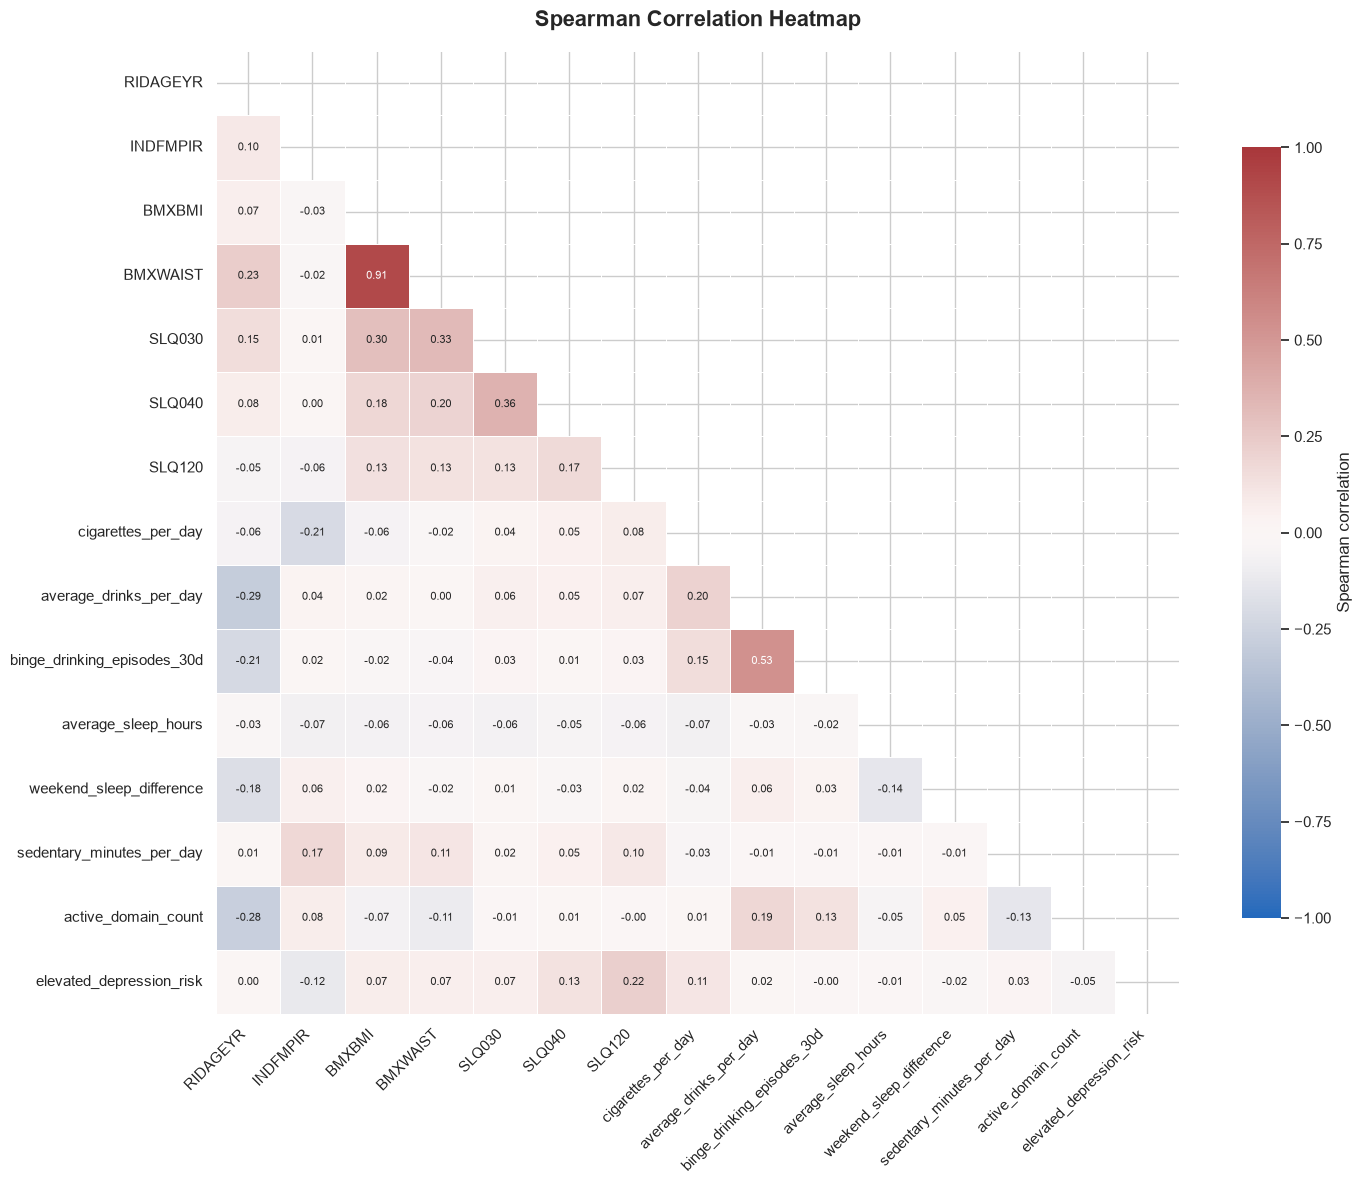

Correlation heatmap saved.
Saved location: ../reports/figures/spearman_correlation_heatmap.png


,spearman_correlation,absolute_correlation
SLQ120,0.219,0.219
SLQ040,0.127,0.127
INDFMPIR,-0.122,0.122
cigarettes_per_day,0.112,0.112
BMXBMI,0.071,0.071
BMXWAIST,0.069,0.069
SLQ030,0.067,0.067
active_domain_count,-0.050,0.050
sedentary_minutes_per_day,0.027,0.027
weekend_sleep_difference,-0.025,0.025


In [9]:
# Select meaningful continuous, count, and ordinal features
# Nominal category codes are excluded because their numeric ordering
# does not represent a true quantitative relationship
correlation_features = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "SLQ030",
    "SLQ040",
    "SLQ120",
    "cigarettes_per_day",
    "average_drinks_per_day",
    "binge_drinking_episodes_30d",
    "average_sleep_hours",
    "weekend_sleep_difference",
    "sedentary_minutes_per_day",
    "active_domain_count",
    target_column,
]

# Calculate the Spearman correlation matrix
correlation_matrix = (
    eda_df[correlation_features]
    .corr(method="spearman")
)

# Create a mask to display only the lower triangle
upper_triangle_mask = np.triu(
    np.ones_like(
        correlation_matrix,
        dtype=bool,
    )
)

# Create the correlation heatmap
fig, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    correlation_matrix,
    mask=upper_triangle_mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Spearman correlation",
        "shrink": 0.8,
    },
    ax=ax,
)

ax.set_title(
    "Spearman Correlation Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=18,
)

plt.xticks(
    rotation=45,
    ha="right",
)
plt.yticks(rotation=0)
plt.tight_layout()

# Save the heatmap
correlation_figure_file = (
    figures_folder
    / "spearman_correlation_heatmap.png"
)

fig.savefig(
    correlation_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Rank correlations with the target by absolute magnitude
target_correlations = (
    correlation_matrix[target_column]
    .drop(target_column)
    .to_frame(name="spearman_correlation")
)

target_correlations["absolute_correlation"] = (
    target_correlations["spearman_correlation"].abs()
)

target_correlations = target_correlations.sort_values(
    by="absolute_correlation",
    ascending=False,
)

print("Correlation heatmap saved.")
print("Saved location:", correlation_figure_file)

target_correlations.round(3)

### Correlation Findings

The Spearman correlation analysis identifies several notable relationships:

- BMI and waist circumference have a very strong positive correlation
  (0.91), indicating substantial multicollinearity.
- Average drinks per drinking day and 30-day binge-drinking episodes have
  a moderate positive relationship.
- Snoring and snorting or interrupted-breathing frequency are positively
  related.
- Daytime sleepiness has the strongest positive individual correlation with
  elevated depression risk among the evaluated numerical features.
- Income-to-poverty ratio has a negative relationship with elevated risk.
- Cigarettes smoked per day has a small positive relationship with elevated
  risk.

Most individual correlations with the target are relatively weak. This
suggests that elevated depression risk is unlikely to be explained by one
feature alone and supports evaluating multivariable and nonlinear machine-
learning models.

Because BMI and waist circumference contain similar information, a later
reduced-feature model may retain only one of these variables. Correlation
does not establish causation.

## 5. Relationship Between BMI and Waist Circumference

A scatterplot is used to examine the strong relationship between BMI and
waist circumference. Points are colored by depression-risk group, while the
black line represents the overall linear trend.

The objective is to visualize predictor redundancy rather than establish a
causal relationship.

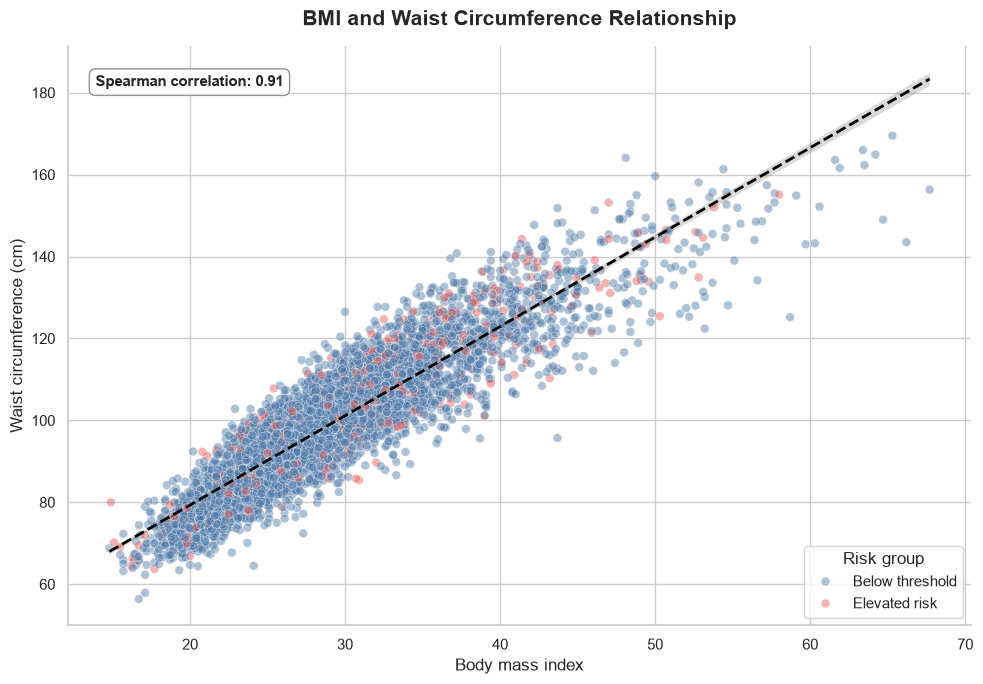

BMI and waist scatterplot saved.
Saved location: ../reports/figures/bmi_waist_scatterplot.png


In [10]:
# Keep records with complete BMI and waist measurements
body_measurement_data = eda_df.dropna(
    subset=[
        "BMXBMI",
        "BMXWAIST",
        "risk_group",
    ]
).copy()

# Calculate the Spearman correlation for annotation
body_measurement_correlation = (
    body_measurement_data[
        ["BMXBMI", "BMXWAIST"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

# Create the scatterplot
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=body_measurement_data,
    x="BMXBMI",
    y="BMXWAIST",
    hue="risk_group",
    palette={
        "Below threshold": "#4C78A8",
        "Elevated risk": "#E45756",
    },
    alpha=0.45,
    s=40,
    ax=ax,
)

# Add an overall regression line
sns.regplot(
    data=body_measurement_data,
    x="BMXBMI",
    y="BMXWAIST",
    scatter=False,
    color="black",
    line_kws={
        "linewidth": 2,
        "linestyle": "--",
    },
    ax=ax,
)

# Format the chart
ax.set_title(
    "BMI and Waist Circumference Relationship",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Body mass index")
ax.set_ylabel("Waist circumference (cm)")

# Add the correlation value
ax.text(
    0.03,
    0.95,
    (
        "Spearman correlation: "
        f"{body_measurement_correlation:.2f}"
    ),
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    va="top",
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.85,
        "edgecolor": "gray",
    },
)

ax.legend(
    title="Risk group",
    frameon=True,
)

sns.despine()
plt.tight_layout()

# Save the scatterplot
body_scatter_file = (
    figures_folder
    / "bmi_waist_scatterplot.png"
)

fig.savefig(
    body_scatter_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("BMI and waist scatterplot saved.")
print("Saved location:", body_scatter_file)

## 6. EDA Summary and Modeling Implications

The exploratory analysis identified several patterns that will guide model development.

### Key Findings

- **Class imbalance:** Elevated depression risk represents 9.06% of eligible participants. Accuracy alone will therefore not be an appropriate model-evaluation metric.
- **Socioeconomic factors:** Elevated-risk participants generally had lower family income-to-poverty ratios and lower educational attainment.
- **Demographic patterns:** Elevated-risk rates differed across gender, race and ethnicity, and marital-status groups.
- **Smoking behavior:** Daily and some-day smokers had higher observed elevated-risk rates than former and never smokers.
- **Sleep characteristics:** Daytime sleepiness (`SLQ120`) had the strongest individual Spearman correlation with the target among the selected numeric predictors.
- **Body measurements:** Elevated-risk participants generally had higher BMI and waist circumference.
- **Multicollinearity:** BMI and waist circumference were strongly correlated (Spearman ρ = 0.91). Their combined use should be evaluated during model development.
- **Individual relationships:** Most predictors had weak individual correlations with the target, suggesting that depression risk is influenced by multiple interacting factors rather than one dominant variable.

### Modeling Implications

The modeling workflow will:

1. Use a stratified train-test split to preserve the target-class distribution.
2. Fit all preprocessing operations using the training data only to prevent data leakage.
3. Impute remaining missing values within the modeling pipeline.
4. Encode categorical variables and scale numeric variables when required.
5. Address class imbalance through class weighting and model-specific strategies.
6. Compare multiple classification algorithms.
7. Evaluate performance using recall, precision, F1-score, ROC-AUC, and precision-recall AUC.
8. Examine feature importance and the effect of correlated predictors.

### Important Limitations

- NHANES 2017–2018 is cross-sectional; observed associations do not establish causality.
- The target represents elevated depressive symptoms based on PHQ-9 scores and is not a clinical diagnosis.
- Several variables are based on self-reported behavior and may contain reporting or recall bias.
- The EDA results are unweighted sample summaries and should not be interpreted as national prevalence estimates.
- Survey design variables and examination weights were preserved separately for possible survey-weighted descriptive analyses.

In [11]:
# List the report figures expected from the EDA notebook
expected_figure_files = [
    "target_class_distribution.png",
    "continuous_feature_distributions.png",
    "continuous_features_by_target.png",
    "categorical_elevated_risk_rates.png",
    "spearman_correlation_heatmap.png",
    "bmi_waist_scatterplot.png",
]

# Check whether each expected figure was created successfully
figure_validation = pd.DataFrame(
    {
        "figure_file": expected_figure_files,
        "file_exists": [
            (figures_folder / filename).exists()
            for filename in expected_figure_files
        ],
    }
)

# Display the figure-validation results
display(figure_validation)

# Confirm that the EDA notebook produced every required figure
all_figures_created = figure_validation["file_exists"].all()

print("EDA validation completed.")
print("All expected figures created:", all_figures_created)
print("Number of observations analyzed:", len(eda_df))
print("Number of elevated-risk cases:", int(eda_df[target_column].sum()))
print(
    "Elevated-risk percentage:",
    f"{eda_df[target_column].mean() * 100:.2f}%",
)

,figure_file,file_exists
0,target_class_distribution.png,True
1,continuous_feature_distributions.png,True
2,continuous_features_by_target.png,True
3,categorical_elevated_risk_rates.png,True
4,spearman_correlation_heatmap.png,True
5,bmi_waist_scatterplot.png,True


EDA validation completed.
All expected figures created: True
Number of observations analyzed: 5068
Number of elevated-risk cases: 459
Elevated-risk percentage: 9.06%
